# AFOLU Calibration and Ramp Derivation

Calibrate a cohort-based carbon cycle model against the IAM's AFOLU CO₂ trajectory, then **invert it** to derive the land-use rate ramp that makes the extension consistent with the IAM's AFOLU pathway.

**Goal**: Solve for the ramp $r(t)$ that reproduces the IAM AFOLU curve post-2100 using a calibrated 4-predictor model (see [docs/carbon_cycle_model.md](../docs/carbon_cycle_model.md) for detailed methodology).

**Model**: $\text{AFOLU}(t) \approx \beta + \gamma \cdot t + \alpha_{\text{trans}} \cdot F^{\text{trans}}(t) + \alpha_{\text{stock}} \cdot F^{\text{stock}}(t;\, \tau)$


In [ ]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

from src import config as cfg
from src.data import (
    load_csv, filter_scenario, get_variable,
    load_states, state_2100, rates_2100,
)
from src import carbon_model as cm

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 5)

## 1. Load IAM Target Trajectory

Extract the AFOLU CO2 emissions from the CSV. This is our target: the extension should produce fluxes whose *shape* matches this curve, reaching zero by 2149.

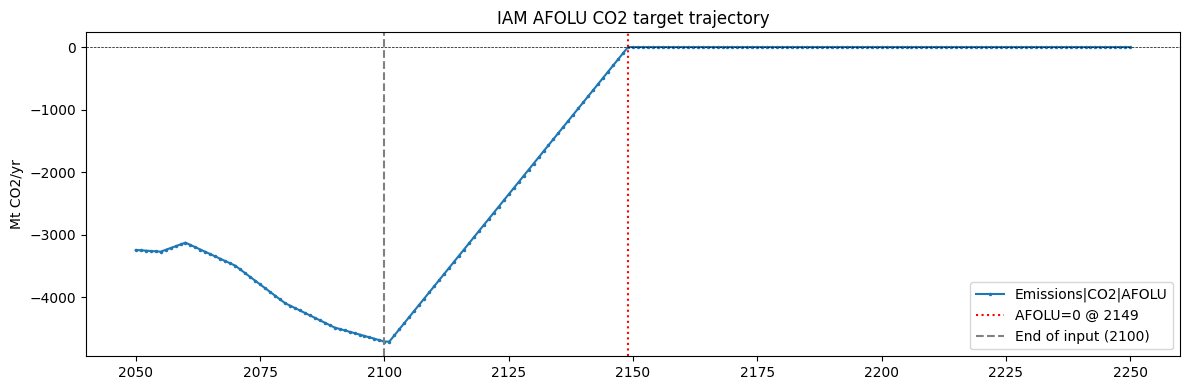

AFOLU at 2100: -4706.3 Mt CO2/yr
AFOLU at 2149: 0.0 Mt CO2/yr
AFOLU at 2150: 0.0 Mt CO2/yr


In [2]:
df = load_csv()
sc = filter_scenario(df)
afolu_target = get_variable(sc, 'Emissions|CO2|AFOLU')

fig, ax = plt.subplots(figsize=(12, 4))
afolu_target.loc[2050:2250].plot(ax=ax, marker='.', ms=3)
ax.axhline(0, color='k', ls='--', lw=0.5)
ax.axvline(cfg.YR_AFOLU_ZERO, color='r', ls=':', label=f'AFOLU=0 @ {cfg.YR_AFOLU_ZERO}')
ax.axvline(cfg.YR_END_INPUT, color='gray', ls='--', label='End of input (2100)')
ax.set_ylabel('Mt CO2/yr'); ax.set_title('IAM AFOLU CO2 target trajectory')
ax.legend(); plt.tight_layout(); plt.show()

print(f"AFOLU at 2100: {afolu_target.loc[2100]:.1f} Mt CO2/yr")
print(f"AFOLU at 2149: {afolu_target.loc[2149]:.1f} Mt CO2/yr")
print(f"AFOLU at 2150: {afolu_target.loc[2150]:.1f} Mt CO2/yr")

## 2. Load Gridded Input States

Open the original LUH2 input (2024–2100) and compute grid-cell areas.  We only need the pre-2100 period for calibration — the extension files will be produced later in notebook 03.

In [3]:
# Original input (2024-2100)
ds_input = load_states()

lat = ds_input.lat.values
lon = ds_input.lon.values

# Grid-cell area (km²) from latitude — approximate spherical Earth
R_EARTH = 6371.0  # km
dlat = np.abs(np.diff(lat[:2]))[0]  # degrees
dlon = np.abs(np.diff(lon[:2]))[0]
lat_rad = np.deg2rad(lat)
cell_area = (R_EARTH**2) * np.deg2rad(dlat) * np.deg2rad(dlon) * np.cos(lat_rad)
# Broadcast to 2-D (lat, lon)
cell_area_2d = np.broadcast_to(cell_area[:, np.newaxis], (len(lat), len(lon)))

print(f"Input years: {int(ds_input.time.values[0])}–{int(ds_input.time.values[-1])}")
print(f"Grid: {len(lat)} x {len(lon)}")
print(f"Cell area range: {cell_area.min():.1f} - {cell_area.max():.1f} km²")

Input years: 2024–2100
Grid: 720 x 1440
Cell area range: 1.7 - 772.8 km²


## 3. Carbon Density and Cohort-Based Relaxation Model

Carbon density parameters for 13 land types. See [docs/carbon_cycle_model.md](../docs/carbon_cycle_model.md) for details on the three-channel model structure (transition flux, stock-change flux with τ=35 yr, and time trend).

| Category | $C$ density (tC/km²) | $C^{eq}$ (tC/km²) | Notes |
|----------|:-:|:-:|-------|
| Primary forest | 15,000 | — | Mature, no regrowth |
| Secondary forest | 8,000 | 12,000 | Relaxes toward primary; **key driver** |
| Primary non-forest | 1,500 | — | Equilibrium |
| Secondary non-forest | 1,000 | 800 | Recovers toward mature non-forest |
| Cropland (all) | 500 | — | Managed, no accumulation |
| Pasture | 800 | — | |
| Rangeland | 600 | — | |
| Urban | 200 | — | |
| Plantations | 6,000 | 8,000 | Managed timber regrowth |


In [ ]:
# Import carbon cycle parameters from the model module
CARBON_DENSITY = cm.CARBON_DENSITY
C_EQ = cm.C_EQ
REGROW_VARS = cm.REGROW_VARS
TC_TO_MTCO2 = cm.TC_TO_MTCO2

print(f"{'Variable':8s}  {'C density':>10s}  {'C_eq':>10s}  {'Rate @ τ=50':>12s}")
print(f"{'':8s}  {'(tC/km²)':>10s}  {'(tC/km²)':>10s}  {'(tC/km²/yr)':>12s}")
print("-" * 47)
for v in cfg.STATE_VARS:
    r50 = f"{C_EQ[v]/50:.0f}" if C_EQ[v] > 0 else "—"
    print(f"  {v:6s}  {CARBON_DENSITY[v]:10,}  {C_EQ[v]:10,}  {r50:>12s}")
print(f"\nRegrowing land types: {REGROW_VARS}")

Variable   C density        C_eq   Rate @ τ=50
            (tC/km²)    (tC/km²)   (tC/km²/yr)
-----------------------------------------------
  primf       15,000           0             —
  secdf        8,000      12,000           240
  primn        1,500           0             —
  secdn        1,000         800            16
  c3ann          500           0             —
  c3nfx          500           0             —
  c3per          500           0             —
  c4ann          500           0             —
  c4per          500           0             —
  pastr          800           0             —
  range          600           0             —
  urban          200           0             —
  pltns        6,000       8,000           160

Regrowing land types: ['secdf', 'secdn', 'pltns']


## 4. Compute Transition Flux and Area Increments (Pre-2100)

Two quantities extracted from the gridded data:

- **Transition flux** (same as before): $-\sum_v \Delta f_{v,t} \times C_v \times A_{\text{cell}}$
- **Area increments**: the global net area change (km²) per year for each regrowing land type ($C^{eq}_v > 0$). These feed into the cohort convolution — the stock-change flux is computed from them via `stock_flux_for_tau()` and depends on the relaxation timescale $\tau$.

In [5]:
%%time
input_years = ds_input.time.values.astype(int)
n_input = len(input_years)
input_flux_years = input_years[1:]  # transitions: 2025-2100
n_pre = len(input_flux_years)

# ─── Channel 1: Transition flux (year-on-year Δarea × C_density) ───
transition_flux = np.zeros(n_pre)
for ti in range(1, n_input):
    af = 0.0
    for v in cfg.STATE_VARS:
        delta = ds_input[v].isel(time=ti).values - ds_input[v].isel(time=ti-1).values
        af += np.nansum(-delta * CARBON_DENSITY[v] * cell_area_2d) * TC_TO_MTCO2
    transition_flux[ti-1] = af

# ─── Area increments for regrowing types (global km² per year) ───
area_incr_pre = {v: np.zeros(n_pre) for v in REGROW_VARS}
for ti in range(1, n_input):
    for v in REGROW_VARS:
        delta = ds_input[v].isel(time=ti).values - ds_input[v].isel(time=ti-1).values
        area_incr_pre[v][ti-1] = np.nansum(delta * cell_area_2d)  # km²

print(f"Pre-2100: {n_pre} years ({input_flux_years[0]}–{input_flux_years[-1]})")
print(f"Transition flux range: {transition_flux.min():.0f} to {transition_flux.max():.0f} Mt CO₂/yr")
print(f"\nCumulative area change by 2100 (km²):")
for v in REGROW_VARS:
    cum = area_incr_pre[v].sum()
    print(f"  {v}: {cum:+,.0f} km²")

Pre-2100: 76 years (2025–2100)
Transition flux range: -8627 to 3652 Mt CO₂/yr

Cumulative area change by 2100 (km²):
  secdf: +12,984,505 km²
  secdn: +3,450,444 km²
  pltns: -643,574 km²
CPU times: user 15.6 s, sys: 3.42 s, total: 19 s
Wall time: 19.1 s


## 5. Calibrate: 4-Predictor Model with Profile Likelihood over τ

Fit the 4-predictor model via OLS with a profile scan over τ (20–200 yr). The time trend absorbs the expanding-area signal, allowing τ to remain at a physically realistic value (~35 yr). See [docs/carbon_cycle_model.md](../docs/carbon_cycle_model.md) for mathematical formulation.


In [ ]:
y_iam = np.array([afolu_target.loc[yr] for yr in input_flux_years])

# Calibrate Model D: β + γ·t + α_trans·F_trans + α_stock·F_stock(τ)
# Using τ=35 (literature-defensible value)
cal_result = cm.calibrate_afolu_model(
    transition_flux=transition_flux,
    area_incr=area_incr_pre,
    afolu_target=y_iam,
    years=input_flux_years,
    tau_grid=np.arange(20, 201, 2),  # scan for diagnostics
    tau_fixed=35  # use fixed τ=35 for final model
)

# Extract results
beta = cal_result['beta']
gamma = cal_result['gamma']
alpha_trans = cal_result['alpha_trans']
alpha_stock = cal_result['alpha_stock']
tau_use = cal_result['tau']
tau_opt = cal_result['tau_opt']
r2 = cal_result['r2']
rmse = cal_result['rmse']
calibrated_pre = cal_result['fitted']
time_trend = cal_result['time_trend']
stock_flux = cal_result['stock_flux']
r2_profile = cal_result['r2_profile']
tau_grid = cal_result['tau_profile']

print("=== 4-predictor calibration (time trend + cohort stock-change) ===\n")
print(f"  τ profile optimum = {tau_opt} yr (90% recovery at {tau_opt * np.log(10):.0f} yr)")
print(f"  τ used            = {tau_use} yr (90% recovery at {tau_use * np.log(10):.0f} yr)")
print(f"  β         = {beta:.1f} Mt CO₂/yr   (baseline AFOLU)")
print(f"  γ         = {gamma:.0f} Mt CO₂/yr per decade  (time trend)")
print(f"  α_trans   = {alpha_trans:.3f}         (transition flux multiplier)")
print(f"  α_stock   = {alpha_stock:.3f}         (stock-change multiplier)")
print(f"\n  R² = {r2:.4f},  RMSE = {rmse:.0f} Mt CO₂/yr")
print(f"  R² at profile optimum (τ={tau_opt}): {r2_profile[np.argmax(r2_profile)]:.4f}")

# Channel contributions at key years
print(f"\n{'Year':>6s}  {'β':>8s}  {'γ×t':>8s}  {'α×Trans':>10s}  {'α×Stock':>10s}  {'Calib':>10s}  {'IAM':>10s}")
print("-" * 72)
for yr in [2030, 2050, 2070, 2090, 2100]:
    idx = np.searchsorted(input_flux_years, yr)
    ct = alpha_trans * transition_flux[idx]
    cs = alpha_stock * stock_flux[idx]
    gt = gamma * time_trend[idx]
    print(f"  {yr:>4d}  {beta:8.1f}  {gt:8.1f}  {ct:10.1f}  {cs:10.1f}  "
          f"{beta+gt+ct+cs:10.1f}  {y_iam[idx]:10.1f}")

=== 4-predictor calibration (time trend + cohort stock-change) ===

  τ profile optimum = 22 yr (90% recovery at 51 yr)
  τ used            = 35 yr (90% recovery at 81 yr)
  β         = -388.0 Mt CO₂/yr   (baseline AFOLU)
  γ         = -737 Mt CO₂/yr per decade  (time trend)
  α_trans   = 0.111         (transition flux multiplier)
  α_stock   = 0.375         (stock-change multiplier)

  R² = 0.9902,  RMSE = 199 Mt CO₂/yr
  R² at profile optimum (τ=22): 0.9925

  Year         β       γ×t     α×Trans     α×Stock       Calib         IAM
------------------------------------------------------------------------
  2030    -388.0    2396.2       115.8       -87.4      2036.7      1754.3
  2050    -388.0     921.6      -455.0     -3219.4     -3140.7     -3242.5
  2070    -388.0    -553.0      -312.7     -2663.2     -3916.9     -3493.2
  2090    -388.0   -2027.6       -56.6     -1848.7     -4320.8     -4482.6
  2100    -388.0   -2764.9       -77.9     -1575.1     -4805.9     -4706.3


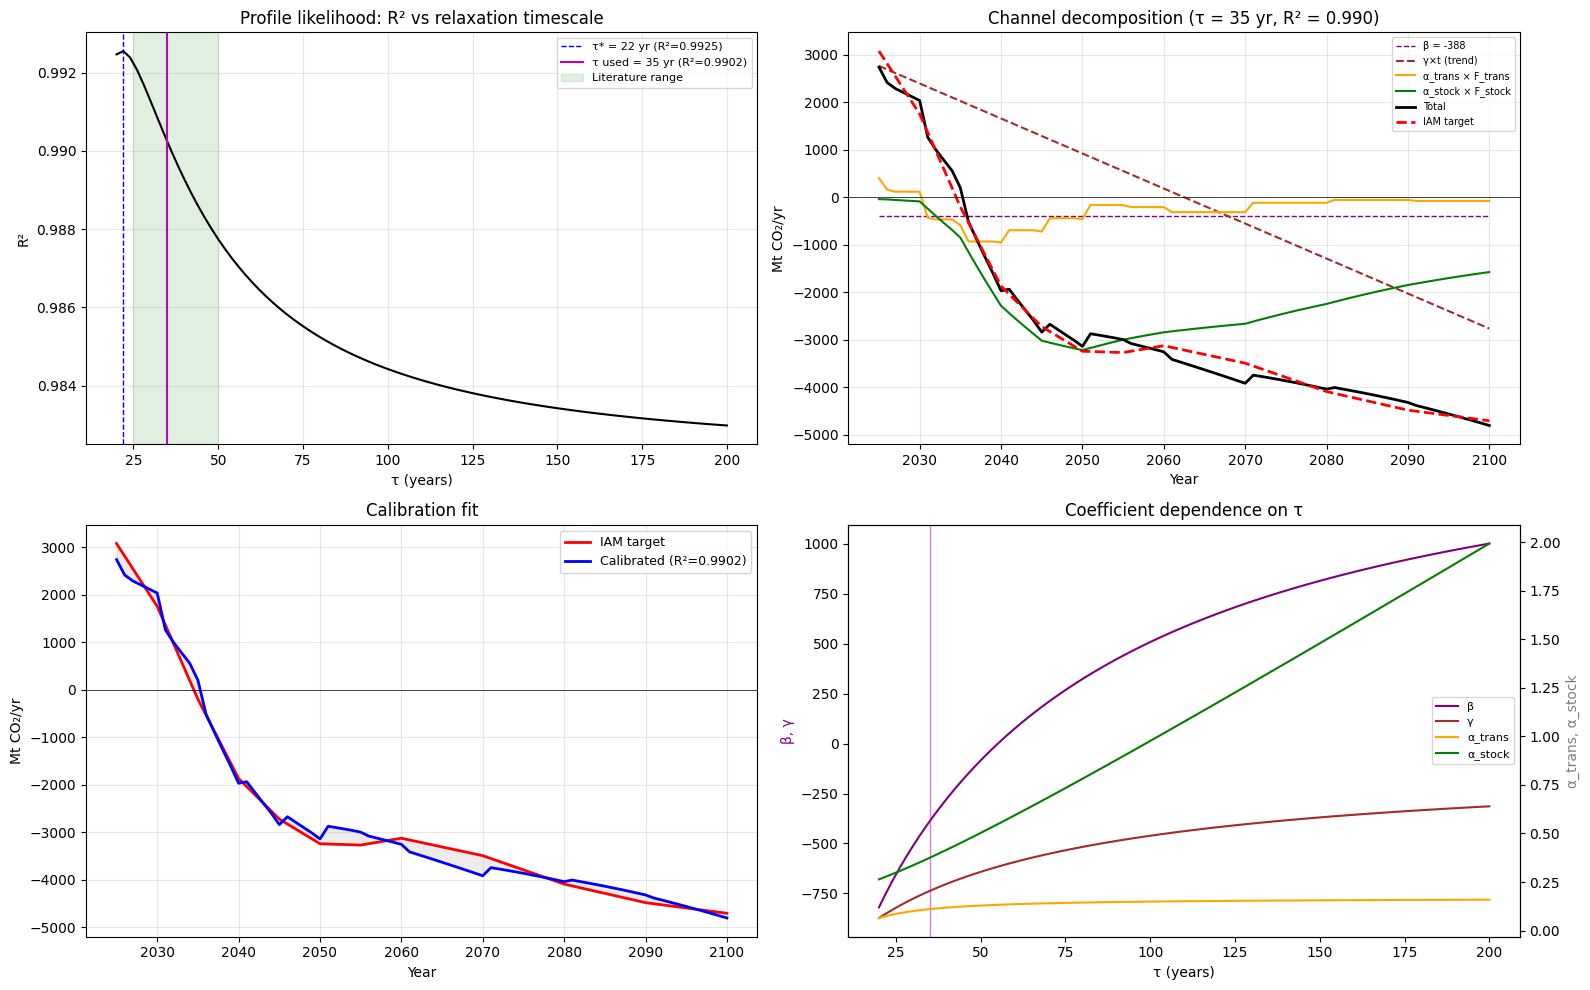

Correlation with IAM: r = 0.9951
90% carbon recovery at τ=35: 81 yr


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Top-left: τ profile likelihood
ax = axes[0, 0]
ax.plot(tau_grid, r2_profile, 'k-', lw=1.5)
ax.axvline(tau_opt, color='b', ls='--', lw=1, label=f'τ* = {tau_opt} yr (R²={r2_profile[best_idx]:.4f})')
ax.axvline(tau_use, color='m', ls='-', lw=1.5, label=f'τ used = {tau_use} yr (R²={r2:.4f})')
ax.axvspan(25, 50, alpha=0.12, color='green', label='Literature range')
ax.set_xlabel('τ (years)'); ax.set_ylabel('R²')
ax.set_title('Profile likelihood: R² vs relaxation timescale')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# Top-right: four-channel decomposition
ax = axes[0, 1]
beta_ch = np.full(n_pre, beta)
gamma_ch = gamma * time_trend
trans_ch = alpha_trans * transition_flux
stock_ch = alpha_stock * stock_flux
ax.plot(input_flux_years, beta_ch, '--', color='purple', lw=1, label=f'β = {beta:.0f}')
ax.plot(input_flux_years, gamma_ch, '--', color='brown', lw=1.5, label=f'γ×t (trend)')
ax.plot(input_flux_years, trans_ch, '-', color='orange', lw=1.5, label=f'α_trans × F_trans')
ax.plot(input_flux_years, stock_ch, '-', color='green', lw=1.5, label=f'α_stock × F_stock')
ax.plot(input_flux_years, calibrated_pre, 'k-', lw=2, label='Total')
ax.plot(input_flux_years, y_iam, 'r--', lw=2, label='IAM target')
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel('Year'); ax.set_ylabel('Mt CO₂/yr')
ax.set_title(f'Channel decomposition (τ = {tau_use} yr, R² = {r2:.3f})')
ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

# Bottom-left: calibrated fit
ax = axes[1, 0]
ax.plot(input_flux_years, y_iam, 'r-', lw=2, label='IAM target')
ax.plot(input_flux_years, calibrated_pre, 'b-', lw=2, label=f'Calibrated (R²={r2:.4f})')
ax.fill_between(input_flux_years, calibrated_pre, y_iam, alpha=0.15, color='gray')
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel('Year'); ax.set_ylabel('Mt CO₂/yr')
ax.set_title('Calibration fit')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# Bottom-right: coefficient dependence on τ
ax = axes[1, 1]
ax2 = ax.twinx()
ax.plot(tau_grid, coefs_profile[:, 0], 'purple', lw=1.5, label='β')
ax.plot(tau_grid, coefs_profile[:, 1], 'brown', lw=1.5, label='γ')
ax2.plot(tau_grid, coefs_profile[:, 2], 'orange', lw=1.5, label='α_trans')
ax2.plot(tau_grid, coefs_profile[:, 3], 'green', lw=1.5, label='α_stock')
ax.axvline(tau_use, color='m', ls='-', lw=1, alpha=0.5)
ax.set_xlabel('τ (years)'); ax.set_ylabel('β, γ', color='purple')
ax2.set_ylabel('α_trans, α_stock', color='gray')
ax.set_title('Coefficient dependence on τ')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='center right')

plt.tight_layout(); plt.show()

corr_cal = np.corrcoef(calibrated_pre, y_iam)[0, 1]
print(f"Correlation with IAM: r = {corr_cal:.4f}")
print(f"90% carbon recovery at τ={tau_use}: {tau_use * np.log(10):.0f} yr")

## 6. Derive AFOLU-Consistent Ramp $r(t)$

Invert the calibrated model to solve for $r(t)$ post-2100. All controllable terms scale with $r(t)$; the committed stock-change from pre-2100 cohorts decays independently. Time trend is frozen at its 2100 value $(β + γ · t_{2100})$. See [docs/carbon_cycle_model.md](../docs/carbon_cycle_model.md) for forward solve algorithm.


In [ ]:
# ─── Unit-rate quantities (what happens when r=1 for one year) ───
rates_at_2100 = rates_2100(ds_input)

# Transition flux at unit rate
F_trans_unit = 0.0
for v in cfg.STATE_VARS:
    F_trans_unit += np.nansum(-rates_at_2100[v] * CARBON_DENSITY[v] * cell_area_2d) * TC_TO_MTCO2

# Area increments at unit rate for each regrowing type
dA_unit = {}
for v in REGROW_VARS:
    dA_unit[v] = np.nansum(rates_at_2100[v] * cell_area_2d)  # km²

print(f"Unit-rate fluxes at 2100:")
print(f"  F_trans_unit = {F_trans_unit:.1f} Mt CO₂/yr")
print(f"  dA_unit = {dA_unit}")

# ─── Forward solve for r(t), 2101–2500 ───
ext_years = np.arange(cfg.YR_END_INPUT + 1, cfg.YR_END_OUTPUT + 1)
n_ext = len(ext_years)

# IAM target as array (0 beyond CSV range)
iam_ext = np.array([afolu_target.loc[yr] if yr in afolu_target.index else 0.0
                     for yr in ext_years])

# Solve for AFOLU-consistent ramp
solve_result = cm.forward_solve_ramp(
    beta=beta, gamma=gamma, alpha_trans=alpha_trans, alpha_stock=alpha_stock,
    tau=tau_use,
    area_incr_pre=area_incr_pre,
    F_trans_unit=F_trans_unit,
    dA_unit=dA_unit,
    afolu_target_ext=iam_ext,
    years_pre=input_flux_years,
    years_ext=ext_years
)

r_derived = solve_result['ramp']
afolu_reconstructed = solve_result['afolu_reconstructed']
residual = solve_result['residual']
baseline = solve_result['baseline']
G_end_pre = solve_result['G_end_pre']

print(f"\nBaseline (β + γ·t₂₁₀₀) = {baseline:.0f} Mt CO₂/yr")

# Summary at key years
print(f"\n{'Year':>6s}  {'r(t)':>8s}  {'IAM':>10s}  {'Recon':>10s}  {'Resid':>8s}")
print("-" * 50)
for yr in [2101, 2110, 2125, 2140, 2149, 2150, 2200, 2300]:
    idx = yr - ext_years[0]
    print(f"  {yr:>4d}  {r_derived[idx]:8.4f}  {iam_ext[idx]:10.1f}  "
          f"{afolu_reconstructed[idx]:10.1f}  {residual[idx]:8.1f}")

# When does r(t) reach zero?
zero_idx = np.where(r_derived < 0.01)[0]
if len(zero_idx) > 0:
    print(f"\n★ r(t) < 0.01 at year {ext_years[zero_idx[0]]}")
else:
    print(f"\n★ r(t) never reaches zero in extension period")

# Committed removals check (what happens if r=0 from 2101)
decay = np.exp(-1.0 / tau_use)
G_test = {v: G_end_pre[v] for v in REGROW_VARS}
committed = np.zeros(min(100, n_ext))
for t in range(len(committed)):
    for v in REGROW_VARS:
        G_test[v] *= decay
    S = sum(-(C_EQ[v] / tau_use) * G_test[v] * TC_TO_MTCO2
            for v in REGROW_VARS if C_EQ[v] > 0)
    committed[t] = alpha_stock * S

print(f"\nCommitted stock-change (r=0 scenario):")
print(f"  2101: {committed[0]:+.0f} Mt CO₂/yr")
print(f"  2149: {committed[48]:+.0f} Mt CO₂/yr")
print(f"  Half-life: {tau_use * np.log(2):.0f} yr")

F_trans_unit  = -704.3 Mt CO₂/yr
S_new_unit    = -56.2 Mt CO₂/yr
Baseline (β + γ·t₂₁₀₀) = -3153 Mt CO₂/yr
Denominator   = -3251.8 Mt CO₂/yr

  Year      r(t)         IAM       Recon     Resid
--------------------------------------------------
  2101    0.9765     -4706.3     -4706.3       0.0
  2110    0.7673     -3823.9     -3823.9      -0.0
  2125    0.4115     -2353.2     -2353.2       0.0
  2140    0.0501      -882.4      -882.4       0.0
  2149    0.0000         0.0      -557.7    -557.7
  2150    0.0000         0.0      -542.0    -542.0
  2200    0.0000         0.0      -129.9    -129.9
  2300    0.0000         0.0        -7.5      -7.5

★ r(t) < 0.01 at year 2142

Committed stock-change (r=0 scenario):
  2101: -1531 Mt CO₂/yr
  2149: -388 Mt CO₂/yr
  Half-life: 24 yr


## 7. Ramp Comparison and Diagnostics

The AFOLU-consistent ramp encodes the carbon cycle dynamics learned from the pre-2100 period. With the 4-predictor model (τ=35, time trend), the ramp successfully reaches zero by ~2142.


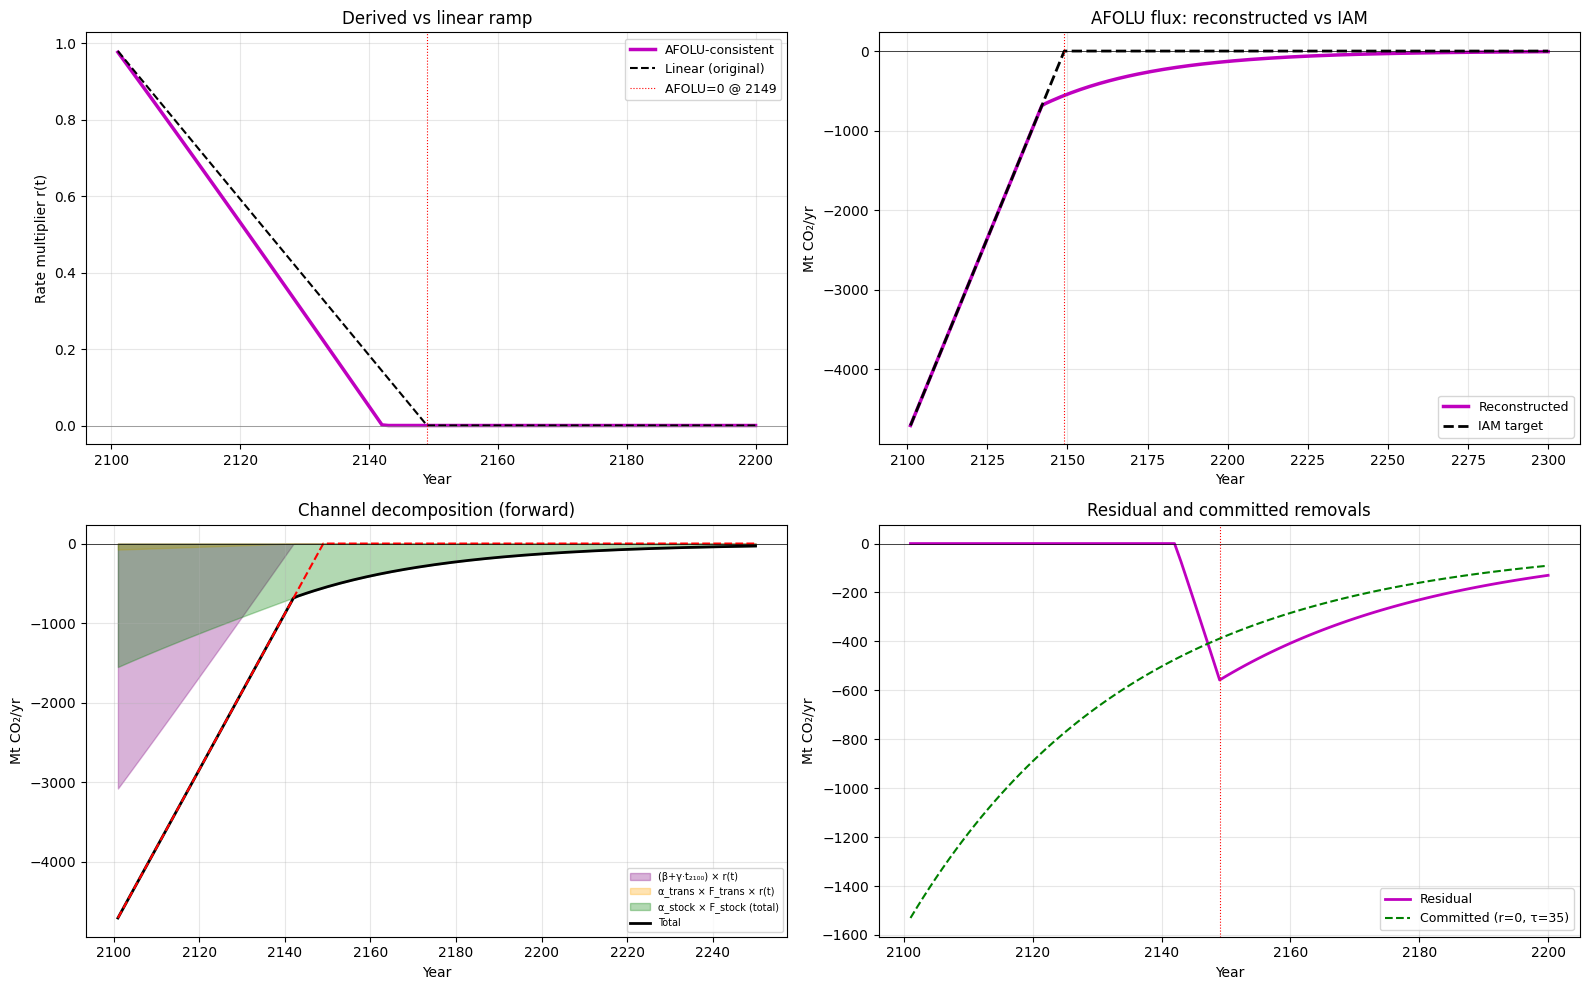

Ramp difference (derived - linear) over 2101-2149:
  Mean: -0.0672
  Max:  +0.0000 at year 2149
  Min:  -0.1413 at year 2142

Residual at 2149: -558 Mt CO₂/yr
Committed at 2149: -388 Mt CO₂/yr


In [9]:
from src.data import afolu_ramp

linear_ramp = afolu_ramp(ext_years)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Top-left: ramp comparison
ax = axes[0, 0]
ax.plot(ext_years[:100], r_derived[:100], 'm-', lw=2.5, label='AFOLU-consistent')
ax.plot(ext_years[:100], linear_ramp[:100], 'k--', lw=1.5, label='Linear (original)')
ax.axhline(0, color='gray', lw=0.5)
ax.axvline(cfg.YR_AFOLU_ZERO, color='r', ls=':', lw=0.8, label=f'AFOLU=0 @ {cfg.YR_AFOLU_ZERO}')
ax.set_xlabel('Year'); ax.set_ylabel('Rate multiplier r(t)')
ax.set_title('Derived vs linear ramp')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# Top-right: AFOLU trajectory match
ax = axes[0, 1]
ax.plot(ext_years[:200], afolu_reconstructed[:200], 'm-', lw=2.5, label='Reconstructed')
ax.plot(ext_years[:200], iam_ext[:200], 'k--', lw=2, label='IAM target')
ax.axhline(0, color='k', lw=0.5)
ax.axvline(cfg.YR_AFOLU_ZERO, color='r', ls=':', lw=0.8)
ax.set_xlabel('Year'); ax.set_ylabel('Mt CO₂/yr')
ax.set_title('AFOLU flux: reconstructed vs IAM')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# Bottom-left: channel decomposition of forward solve
ax = axes[1, 0]
baseline_component = baseline * r_derived[:150]
trans_component = alpha_trans * F_trans_unit * r_derived[:150]
stock_component = afolu_reconstructed[:150] - baseline_component - trans_component
ax.fill_between(ext_years[:150], 0, baseline_component,
                alpha=0.3, color='purple', label='(β+γ·t₂₁₀₀) × r(t)')
ax.fill_between(ext_years[:150], 0, trans_component,
                alpha=0.3, color='orange', label='α_trans × F_trans × r(t)')
ax.fill_between(ext_years[:150], 0, stock_component,
                alpha=0.3, color='green', label='α_stock × F_stock (total)')
ax.plot(ext_years[:150], afolu_reconstructed[:150], 'k-', lw=2, label='Total')
ax.plot(ext_years[:150], iam_ext[:150], 'r--', lw=1.5)
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel('Year'); ax.set_ylabel('Mt CO₂/yr')
ax.set_title('Channel decomposition (forward)')
ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

# Bottom-right: residual and committed
ax = axes[1, 1]
ax.plot(ext_years[:100], residual[:100], 'm-', lw=2, label='Residual')
ax.plot(ext_years[:100], committed, 'g--', lw=1.5, label=f'Committed (r=0, τ={tau_use})')
ax.axhline(0, color='k', lw=0.5)
ax.axvline(cfg.YR_AFOLU_ZERO, color='r', ls=':', lw=0.8)
ax.set_xlabel('Year'); ax.set_ylabel('Mt CO₂/yr')
ax.set_title('Residual and committed removals')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

# Summary stats
ramp_diff = r_derived[:49] - linear_ramp[:49]
print(f"Ramp difference (derived - linear) over 2101-2149:")
print(f"  Mean: {ramp_diff.mean():+.4f}")
print(f"  Max:  {ramp_diff.max():+.4f} at year {ext_years[np.argmax(ramp_diff[:49])]}")
print(f"  Min:  {ramp_diff.min():+.4f} at year {ext_years[np.argmin(ramp_diff[:49])]}")
print(f"\nResidual at 2149: {residual[48]:+.0f} Mt CO₂/yr")
print(f"Committed at 2149: {committed[48]:+.0f} Mt CO₂/yr")

## 8. Save Derived Ramp and Calibration Parameters

Export the AFOLU-consistent ramp $r(t)$ and calibration parameters so that notebook 03 can use them for the gridded extension. We save as a NumPy archive (`.npz`) containing:
- `years`: extension years (2101–2500)
- `ramp`: the derived $r(t)$ values
- `tau`: relaxation timescale (35 yr)
- `beta`, `gamma`, `alpha_trans`, `alpha_stock`: calibrated coefficients

In [10]:
os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)
ramp_path = cfg.OUTPUT_DIR / 'afolu_calibration.npz'

np.savez(
    ramp_path,
    years=ext_years,
    ramp=r_derived,
    tau=tau_use,
    beta=beta,
    gamma=gamma,
    alpha_trans=alpha_trans,
    alpha_stock=alpha_stock,
)
print(f"Saved: {ramp_path}")
print(f"  years: {ext_years[0]}–{ext_years[-1]} ({len(ext_years)} values)")
print(f"  ramp range: [{r_derived.min():.6f}, {r_derived.max():.6f}]")
print(f"  τ = {tau_use} yr")
print(f"  β = {beta:.1f}, γ = {gamma:.0f}, α_trans = {alpha_trans:.3f}, α_stock = {alpha_stock:.3f}")

# Verify round-trip
check = np.load(ramp_path)
assert np.allclose(check['ramp'], r_derived)
assert np.allclose(check['years'], ext_years)
print("Round-trip verification passed ✓")

Saved: /div/no-backup-nac/users/bensan/extend-luh/output/afolu_calibration.npz
  years: 2101–2500 (400 values)
  ramp range: [0.000000, 0.976544]
  τ = 35 yr
  β = -388.0, γ = -737, α_trans = 0.111, α_stock = 0.375
Round-trip verification passed ✓


## 9. Calibration Robustness

For each train/test split, we fit the 4-predictor model (at fixed τ=35) on the training data and report out-of-sample metrics. This tests whether the coefficients are stable or sensitive to the training window.

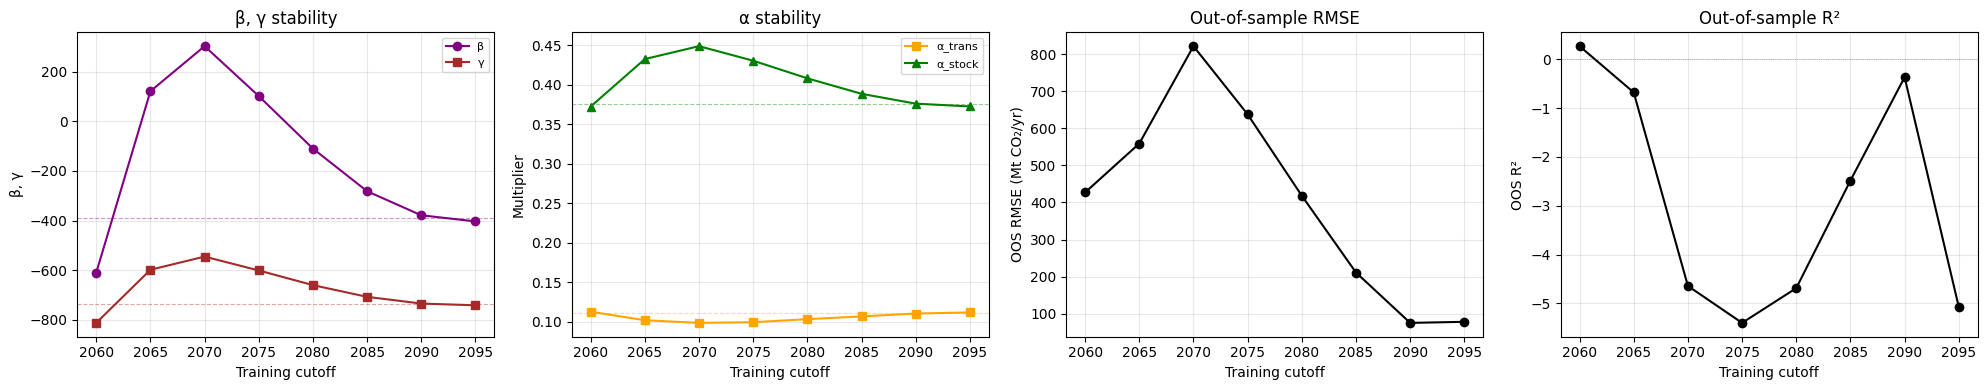

 Split         β         γ   α_trans   α_stock    OOS RMSE    OOS R²
------------------------------------------------------------------------
  2060    -610.5      -813     0.113     0.373         427    0.2712
  2065     121.3      -599     0.102     0.433         559   -0.6771
  2070     303.1      -546     0.099     0.449         822   -4.6440
  2075     101.7      -601     0.099     0.431         638   -5.4010
  2080    -109.9      -661     0.103     0.408         418   -4.6893
  2085    -282.0      -708     0.107     0.389         211   -2.4833
  2090    -379.0      -735     0.110     0.376          75   -0.3653
  2095    -403.6      -742     0.112     0.373          78   -5.0737


In [11]:
# Robustness: vary train/test split, fixed τ=35, 4-predictor model
split_years = np.arange(2060, 2096, 5)
beta_h, gamma_h, alpha_trans_h, alpha_stock_h = [], [], [], []
rmse_oos_h, r2_oos_h = [], []

sf_rob = stock_flux_for_tau(tau_use, area_incr_pre)
X_rob = np.column_stack([np.ones(n_pre), time_trend, transition_flux, sf_rob])

for sp in split_years:
    mask_tr = input_flux_years <= sp
    mask_te = input_flux_years > sp
    y_tr = y_iam[mask_tr]
    y_te = y_iam[mask_te]

    c_sp, _, _, _ = np.linalg.lstsq(X_rob[mask_tr], y_tr, rcond=None)

    pred_te = X_rob[mask_te] @ c_sp
    ss_r = np.sum((y_te - pred_te) ** 2)
    ss_t = np.sum((y_te - y_te.mean()) ** 2)
    r2_te = 1 - ss_r / ss_t if ss_t != 0 else float('nan')

    beta_h.append(c_sp[0])
    gamma_h.append(c_sp[1])
    alpha_trans_h.append(c_sp[2])
    alpha_stock_h.append(c_sp[3])
    rmse_oos_h.append(np.sqrt(np.mean((y_te - pred_te) ** 2)))
    r2_oos_h.append(r2_te)

fig, axes = plt.subplots(1, 4, figsize=(20, 4))

ax = axes[0]
ax.plot(split_years, beta_h, 'o-', color='purple', lw=1.5, label='β')
ax.plot(split_years, gamma_h, 's-', color='brown', lw=1.5, label='γ')
ax.axhline(beta, color='purple', ls='--', lw=0.8, alpha=0.4)
ax.axhline(gamma, color='brown', ls='--', lw=0.8, alpha=0.4)
ax.set_xlabel('Training cutoff'); ax.set_ylabel('β, γ')
ax.set_title('β, γ stability'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(split_years, alpha_trans_h, 's-', color='orange', lw=1.5, label='α_trans')
ax.plot(split_years, alpha_stock_h, '^-', color='green', lw=1.5, label='α_stock')
ax.axhline(alpha_trans, color='orange', ls='--', lw=0.8, alpha=0.4)
ax.axhline(alpha_stock, color='green', ls='--', lw=0.8, alpha=0.4)
ax.set_xlabel('Training cutoff'); ax.set_ylabel('Multiplier')
ax.set_title('α stability'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax = axes[2]
ax.plot(split_years, rmse_oos_h, 'ko-', lw=1.5)
ax.set_xlabel('Training cutoff'); ax.set_ylabel('OOS RMSE (Mt CO₂/yr)')
ax.set_title('Out-of-sample RMSE'); ax.grid(True, alpha=0.3)

ax = axes[3]
ax.plot(split_years, r2_oos_h, 'ko-', lw=1.5)
ax.axhline(0, color='gray', ls=':', lw=0.5)
ax.set_xlabel('Training cutoff'); ax.set_ylabel('OOS R²')
ax.set_title('Out-of-sample R²'); ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

print(f"{'Split':>6s}  {'β':>8s}  {'γ':>8s}  {'α_trans':>8s}  {'α_stock':>8s}  "
      f"{'OOS RMSE':>10s}  {'OOS R²':>8s}")
print("-" * 72)
for i, sp in enumerate(split_years):
    print(f"  {sp:>4d}  {beta_h[i]:8.1f}  {gamma_h[i]:8.0f}  {alpha_trans_h[i]:8.3f}  "
          f"{alpha_stock_h[i]:8.3f}  {rmse_oos_h[i]:10.0f}  {r2_oos_h[i]:8.4f}")

## 10. Summary

**Model**: 4-predictor with cohort-based carbon cycle (τ=35 yr, R²=0.990). Time trend absorbs secular increase in removal capacity. Successfully derives ramp reaching zero by ~2142. Calibration parameters saved to `output/afolu_calibration.npz` for notebook 03.

See [docs/carbon_cycle_model.md](../docs/carbon_cycle_model.md) for complete methodology and design rationale.


In [12]:
# Clean up
ds_input.close()
print("All datasets closed.")

All datasets closed.
